# Trabajo Final de Machine Learning - Ejercicio 3
## Clustering: perfiles de clientes mayoristas

**Grupo:** F
**Integrantes:**
- Alexis Gonzalez
- Luis Morales
- Alexia Orce
- Georgina Sicco
- Emiliano Prockoff

Se comparan K-Means y DBSCAN para identificar perfiles de clientes a partir de sus gastos anuales por categoria.

## 1. Metadata y planteamiento

El dataset Wholesale Customers contiene 440 clientes, con canal, region y gasto anual en Fresh, Milk, Grocery, Frozen, Detergents_Paper y Delicassen. Para clustering se excluyen `Channel` y `Region`, porque el objetivo es descubrir perfiles basados en comportamiento de compra, no reproducir etiquetas administrativas.

Pregunta: **es posible distinguir grupos de clientes con patrones de gasto diferentes?**

## Contexto del rubro: distribucion mayorista

La distribución mayorista conecta proveedores con comercios, restaurantes, hoteles y otros clientes profesionales. Estos clientes pueden comprar grandes volúmenes de productos de distintas categorías, y sus necesidades de reposición no son todas iguales.

El dataset resume el gasto anual de cada cliente en productos frescos, lácteos, almacén, congelados, detergentes y papel, y delicatessen. También informa el canal de compra y la región, que sirven para describir el negocio pero no se utilizan para construir los grupos.

Conocer perfiles de compra puede ayudar a organizar visitas comerciales, definir surtidos, planificar inventario y diseñar promociones más relevantes. Por ejemplo, un cliente especializado en productos frescos puede requerir una estrategia distinta de otro con alto gasto en almacén y detergentes.

El clustering busca descubrir esos perfiles sin una etiqueta previa. Los grupos encontrados deben interpretarse con criterio comercial y validarse con la experiencia del negocio; un segmento matemáticamente bien separado no siempre es automáticamente una categoría útil para tomar decisiones.

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples, davies_bouldin_score

sns.set_theme(style='whitegrid', palette='deep')
RANDOM_STATE = 42

In [2]:
DATA_PATH = Path('datasets/Wholesale_customers_data.csv')
if not DATA_PATH.exists():
    raise FileNotFoundError(f'No se encontro el dataset: {DATA_PATH.resolve()}')

df = pd.read_csv(DATA_PATH)
print(f'Dimensiones: {df.shape}')
display(df.head())
display(df.describe().T)

Dimensiones: (440, 8)


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


,count,mean,std,min,25%,50%,75%,max
Channel,440.0,1.322727,0.468052,1.0,1.00,1.0,2.00,2.0
Region,440.0,2.543182,0.774272,1.0,2.00,3.0,3.00,3.0
Fresh,440.0,12000.297727,12647.328865,3.0,3127.75,8504.0,16933.75,112151.0
Milk,440.0,5796.265909,7380.377175,55.0,1533.00,3627.0,7190.25,73498.0
Grocery,440.0,7951.277273,9503.162829,3.0,2153.00,4755.5,10655.75,92780.0
Frozen,440.0,3071.931818,4854.673333,25.0,742.25,1526.0,3554.25,60869.0
Detergents_Paper,440.0,2881.493182,4767.854448,3.0,256.75,816.5,3922.00,40827.0
Delicassen,440.0,1524.870455,2820.105937,3.0,408.25,965.5,1820.25,47943.0


Valores faltantes: 0


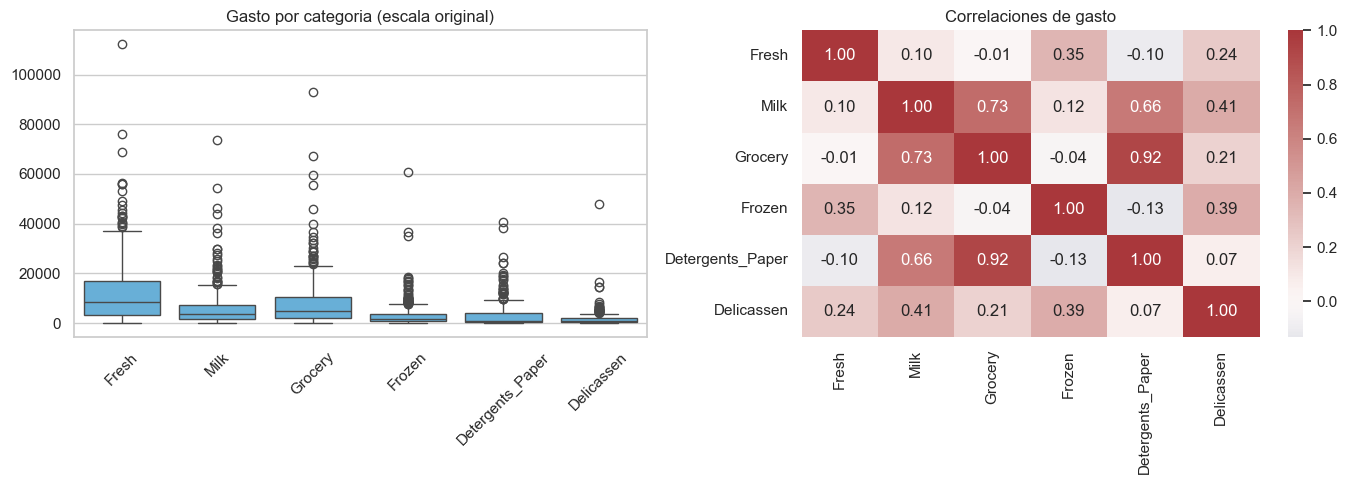

In [3]:
spending_cols = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']
print('Valores faltantes:', df[spending_cols].isna().sum().sum())
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df[spending_cols], ax=axes[0], color='#56b4e9')
axes[0].set_title('Gasto por categoria (escala original)')
axes[0].tick_params(axis='x', rotation=45)
sns.heatmap(df[spending_cols].corr(), cmap='vlag', center=0, annot=True, fmt='.2f', ax=axes[1])
axes[1].set_title('Correlaciones de gasto')
plt.tight_layout()
plt.show()

# La transformacion log reduce el peso de valores extremos sin eliminar clientes.
X_log = np.log1p(df[spending_cols])
X_scaled = StandardScaler().fit_transform(X_log)

### Hallazgos de los gráficos

- **Gasto por categoría:** todas las categorías presentan clientes con compras muy superiores al comportamiento habitual. Las diferencias de escala y los valores extremos justifican transformar los datos antes de aplicar algoritmos basados en distancias.
- **Correlaciones de gasto:** Grocery, Milk y Detergents_Paper forman el bloque de asociaciones positivas más fuerte. Fresh se comporta de forma más independiente, lo que anticipa perfiles de clientes orientados a productos frescos frente a otros con mayor compra de almacén y limpieza.

## 2. Analisis de las variables utilizadas para clustering

Las variables utilizadas para agrupar son los gastos anuales en seis categorias: Fresh, Milk, Grocery, Frozen, Detergents_Paper y Delicassen. No se utilizan `Channel` ni `Region` para que los grupos reflejen el comportamiento de compra.

- Los histogramas muestran la distribucion de cada categoria.
- Los diagramas de dispersion permiten observar pares de categorias que podrían moverse juntas.
- Los perfiles relativos ayudan a distinguir clientes especializados de clientes con compras diversificadas.

Este paso es importante porque los valores extremos y las diferencias de escala pueden afectar fuertemente la distancia entre clientes.

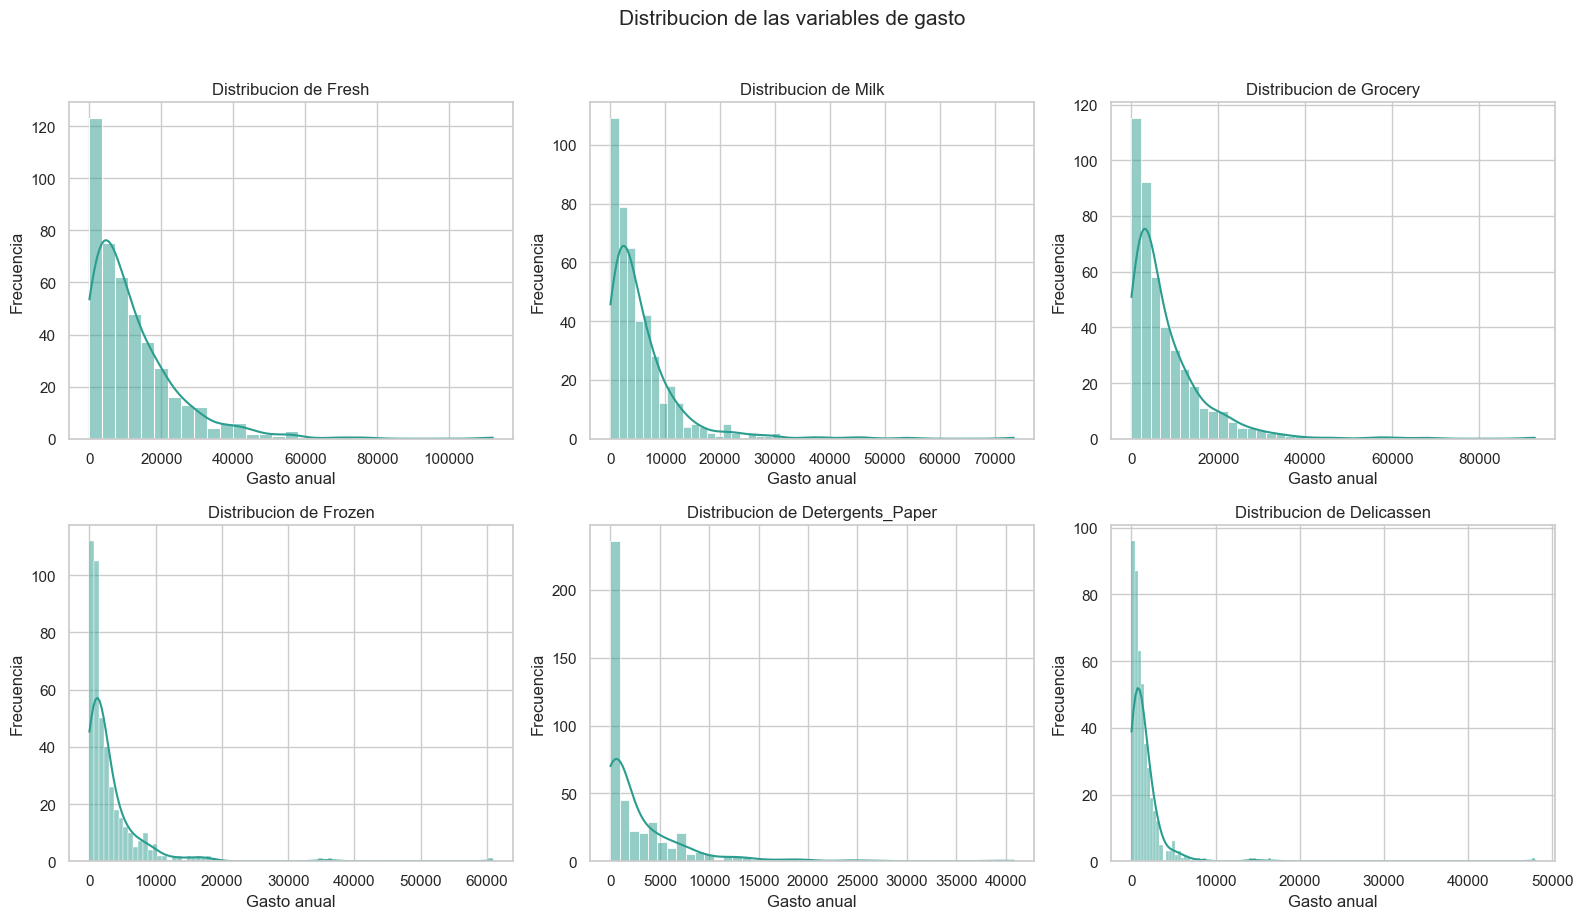

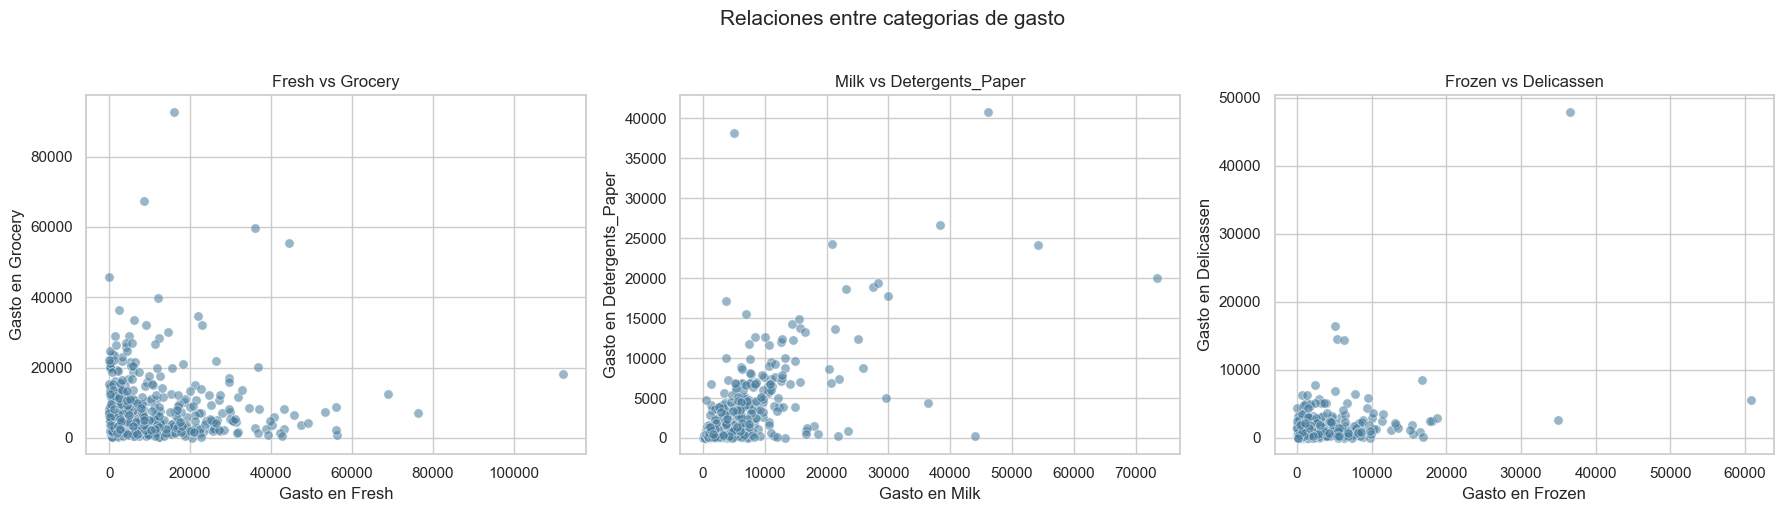

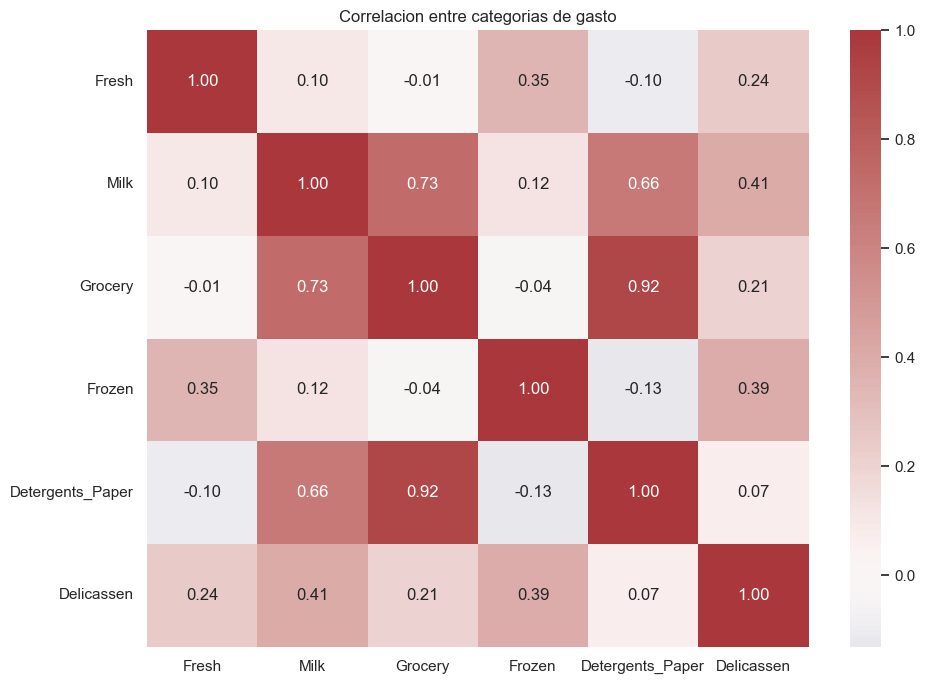

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, column in zip(axes.ravel(), spending_cols):
    sns.histplot(data=df, x=column, kde=True, ax=ax, color='#2a9d8f')
    ax.set_title(f'Distribucion de {column}')
    ax.set_xlabel('Gasto anual')
    ax.set_ylabel('Frecuencia')
plt.suptitle('Distribucion de las variables de gasto', y=1.02, fontsize=15)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
spending_pairs = [('Fresh', 'Grocery'), ('Milk', 'Detergents_Paper'), ('Frozen', 'Delicassen')]
for ax, (x_column, y_column) in zip(axes, spending_pairs):
    sns.scatterplot(data=df, x=x_column, y=y_column, alpha=0.55, s=45, ax=ax, color='#457b9d')
    ax.set_title(f'{x_column} vs {y_column}')
    ax.set_xlabel(f'Gasto en {x_column}')
    ax.set_ylabel(f'Gasto en {y_column}')
plt.suptitle('Relaciones entre categorias de gasto', y=1.02, fontsize=15)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 7))
sns.heatmap(df[spending_cols].corr(), annot=True, fmt='.2f', cmap='vlag', center=0)
plt.title('Correlacion entre categorias de gasto')
plt.tight_layout()
plt.show()

### Hallazgos de los gráficos

- **Distribuciones por categoría:** las seis variables tienen asimetría positiva: hay muchos clientes de gasto bajo o medio y pocos compradores de volumen muy alto. Delicassen y Frozen son las más asimétricas, por lo que la transformación `log1p` evita que unos pocos clientes dominen las distancias.
- **Relaciones entre pares:** Milk y Detergents_Paper muestran la relación positiva más clara. Fresh y Grocery presentan perfiles más dispersos, mientras que Frozen y Delicassen tienen una asociación positiva más débil y varios casos extremos.
- **Mapa de correlaciones:** confirma que Grocery, Milk y Detergents_Paper tienden a crecer juntas. Esto permite que el clustering distinga patrones de composición del gasto, no solamente clientes con mayor gasto total.

## 2.1. EDA profundo: estructura de clientes y valores extremos

Profundizamos en la composición del gasto total, la asimetría de cada categoría, los clientes con consumo nulo o muy elevado y las relaciones entre categorías. Este diagnóstico justifica la transformación logarítmica y la estandarización usadas antes de agrupar.

Registros duplicados: 0


,faltantes,unicos,asimetria,mediana,maximo
Fresh,0,433,2.56,8504.0,112151
Milk,0,421,4.05,3627.0,73498
Grocery,0,430,3.59,4755.5,92780
Frozen,0,426,5.91,1526.0,60869
Detergents_Paper,0,417,3.63,816.5,40827
Delicassen,0,403,11.15,965.5,47943


Clientes sin gasto en ninguna categoria: 0


,total_spending,active_categories
count,440.00,440.0
mean,33226.14,6.0
std,26356.30,0.0
min,904.00,6.0
25%,17448.75,6.0
50%,27492.00,6.0
75%,41307.50,6.0
max,199891.00,6.0


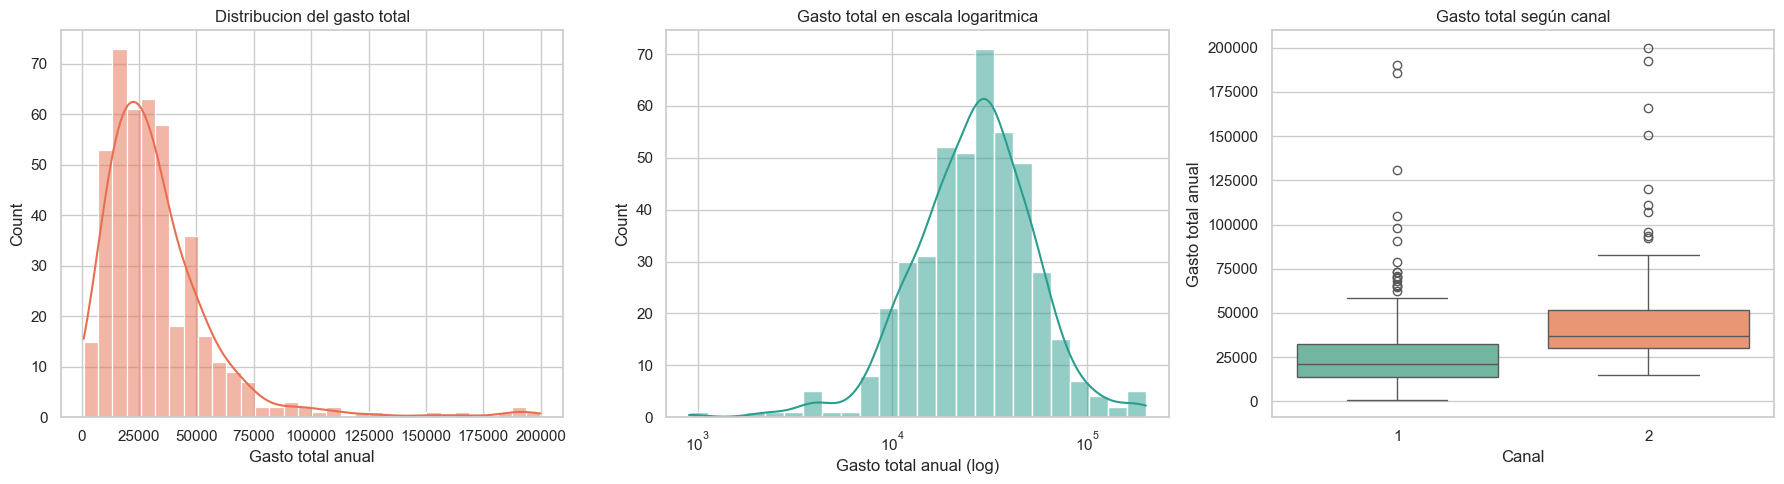

,0.01,0.25,0.50,0.75,0.99
Fresh,28.0,3128.0,8504.0,16934.0,56083.0
Milk,256.0,1533.0,3627.0,7190.0,37610.0
Grocery,260.0,2153.0,4756.0,10656.0,43436.0
Frozen,44.0,742.0,1526.0,3554.0,17965.0
Detergents_Paper,9.0,257.0,816.0,3922.0,22572.0
Delicassen,7.0,408.0,966.0,1820.0,8275.0


,participacion_promedio
Fresh,37.50%
Grocery,22.97%
Milk,16.75%
Frozen,10.58%
Detergents_Paper,7.42%
Delicassen,4.78%


In [5]:
df['total_spending'] = df[spending_cols].sum(axis=1)
df['active_categories'] = (df[spending_cols] > 0).sum(axis=1)

quality_summary = pd.DataFrame({
    'faltantes': df[spending_cols].isna().sum(),
    'unicos': df[spending_cols].nunique(),
    'asimetria': df[spending_cols].skew(),
    'mediana': df[spending_cols].median(),
    'maximo': df[spending_cols].max()
})
print('Registros duplicados:', df.duplicated().sum())
display(quality_summary.round(2))
print('Clientes sin gasto en ninguna categoria:', (df['total_spending'] == 0).sum())
display(df[['total_spending', 'active_categories']].describe().round(2))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(data=df, x='total_spending', kde=True, ax=axes[0], color='#e76f51')
axes[0].set_title('Distribucion del gasto total')
axes[0].set_xlabel('Gasto total anual')
sns.histplot(data=df, x='total_spending', kde=True, log_scale=True, ax=axes[1], color='#2a9d8f')
axes[1].set_title('Gasto total en escala logaritmica')
axes[1].set_xlabel('Gasto total anual (log)')
sns.boxplot(data=df, x='Channel', y='total_spending', hue='Channel', legend=False, ax=axes[2], palette='Set2')
axes[2].set_title('Gasto total según canal')
axes[2].set_xlabel('Canal')
axes[2].set_ylabel('Gasto total anual')
plt.tight_layout()
plt.show()

spending_quantiles = df[spending_cols].quantile([0.01, 0.25, 0.50, 0.75, 0.99]).T.round(0)
display(spending_quantiles)

profile_share = df[spending_cols].div(df[spending_cols].sum(axis=1).replace(0, np.nan), axis=0).mean().sort_values(ascending=False)
display(profile_share.rename('participacion_promedio').to_frame().style.format({'participacion_promedio': '{:.2%}'}))

### Hallazgos de los gráficos

- **Gasto total en escala original:** la distribución tiene una cola derecha pronunciada; la mediana es 27.492 y el máximo 199.891. La media superior a la mediana confirma la influencia de compradores de gran volumen.
- **Escala logarítmica:** la transformación comprime los valores extremos y produce una distribución más equilibrada, adecuada para comparar clientes mediante distancias.
- **Gasto según canal:** los canales muestran distribuciones y dispersiones distintas, aunque `Channel` no se usa para formar los grupos. Sirve como contraste externo para comprobar si los perfiles descubiertos guardan relación con una segmentación comercial conocida.

## 3. K-Means

Se usa `log1p` para reducir la asimetria de los gastos y luego se estandarizan las variables. Se comparan varios valores de K usando silhouette y Davies-Bouldin.

In [6]:
k_rows = []
for k in range(2, 9):
    labels = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE).fit_predict(X_scaled)
    k_rows.append({'K': k, 'Silhouette': silhouette_score(X_scaled, labels), 'Davies-Bouldin': davies_bouldin_score(X_scaled, labels)})
k_results = pd.DataFrame(k_rows)
display(k_results.style.format({'Silhouette':'{:.3f}', 'Davies-Bouldin':'{:.3f}'}))
best_k = int(k_results.loc[k_results['Silhouette'].idxmax(), 'K'])
kmeans = KMeans(n_clusters=best_k, n_init=30, random_state=RANDOM_STATE)
df['kmeans_cluster'] = kmeans.fit_predict(X_scaled)
print('K elegido por silhouette:', best_k)

,K,Silhouette,Davies-Bouldin
0,2,0.290,1.352
1,3,0.258,1.348
2,4,0.188,1.541
3,5,0.192,1.484
4,6,0.195,1.414
5,7,0.196,1.392
6,8,0.191,1.385


K elegido por silhouette: 2


## 4. DBSCAN

DBSCAN identifica regiones densas y permite marcar observaciones atipicas como ruido (`-1`). Se prueba una pequeña grilla de hiperparametros y se descartan configuraciones con un unico grupo valido.

In [7]:
db_rows = []
for eps in [0.7, 0.9, 1.1, 1.3, 1.5]:
    for min_samples in [4, 6, 10]:
        labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(X_scaled)
        valid = labels != -1
        groups = set(labels[valid])
        if valid.sum() > 1 and len(groups) >= 2:
            db_rows.append({'eps': eps, 'min_samples': min_samples, 'grupos': len(groups), 'ruido_%': 100 * (~valid).mean(), 'Silhouette_sin_ruido': silhouette_score(X_scaled[valid], labels[valid])})
db_results = pd.DataFrame(db_rows).sort_values('Silhouette_sin_ruido', ascending=False)
display(db_results.head(10).style.format({'ruido_%':'{:.1f}', 'Silhouette_sin_ruido':'{:.3f}'}))
if db_results.empty:
    raise ValueError('La grilla de DBSCAN no produjo al menos dos grupos validos.')
best_db = db_results.iloc[0]
dbscan = DBSCAN(eps=float(best_db['eps']), min_samples=int(best_db['min_samples']))
df['dbscan_cluster'] = dbscan.fit_predict(X_scaled)
print('DBSCAN seleccionado:', dict(best_db))

,eps,min_samples,grupos,ruido_%,Silhouette_sin_ruido
4,0.900000,10,2,56.4,0.461
6,1.100000,10,2,27.7,0.261
1,0.700000,6,5,83.0,0.245
5,1.100000,4,2,18.6,0.154
0,0.700000,4,13,66.4,0.106
3,0.900000,6,4,39.8,0.024
2,0.900000,4,4,34.3,-0.136


DBSCAN seleccionado: {'eps': np.float64(0.9), 'min_samples': np.float64(10.0), 'grupos': np.float64(2.0), 'ruido_%': np.float64(56.36363636363636), 'Silhouette_sin_ruido': np.float64(0.46131726810181645)}


## 5. Resultados obtenidos

Se visualizan los grupos, sus tamaños y sus perfiles de gasto para comparar K-Means y DBSCAN.

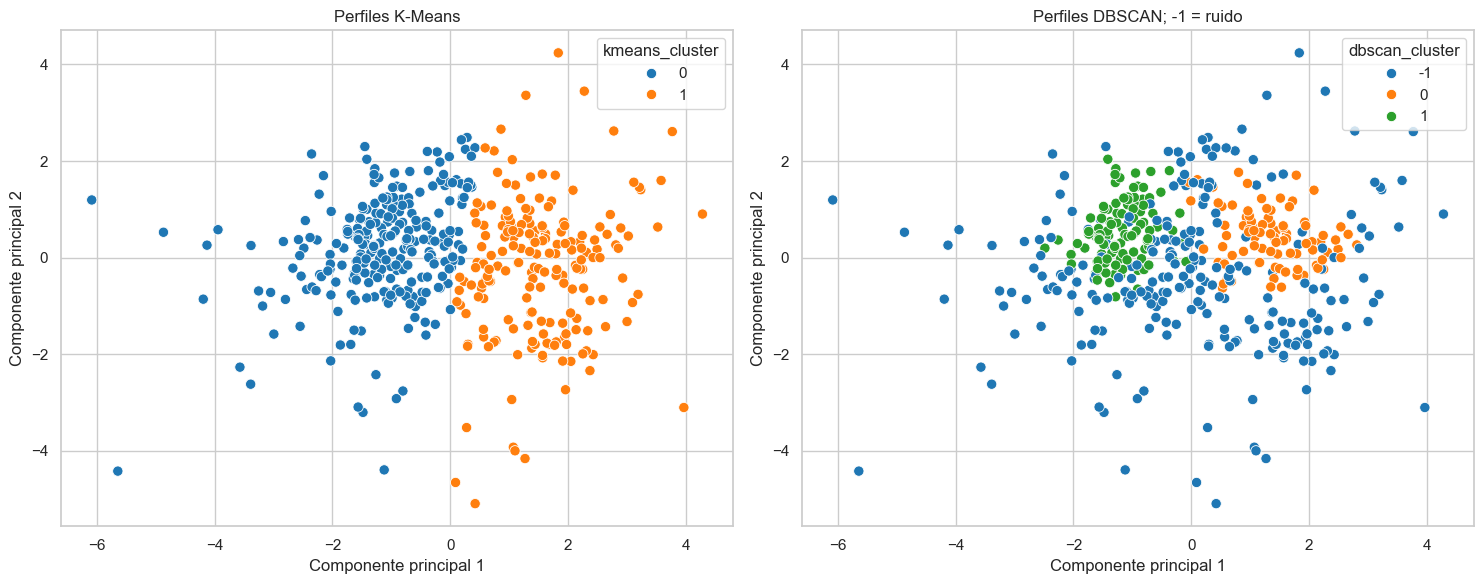

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
kmeans_cluster,,,,,,
0,10348.0,1871.0,2406.0,2225.0,328.0,750.0
1,5406.0,7690.0,11527.0,1062.0,4495.0,1388.0


Cantidad de clientes por cluster K-Means:


,clientes
kmeans_cluster,
0,252
1,188


Cantidad de clientes por cluster DBSCAN:


,clientes
dbscan_cluster,
-1,248
0,88
1,104


In [8]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(X_scaled)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.scatterplot(x=coords[:, 0], y=coords[:, 1], hue=df['kmeans_cluster'], palette='tab10', ax=axes[0], s=55)
axes[0].set_title('Perfiles K-Means')
sns.scatterplot(x=coords[:, 0], y=coords[:, 1], hue=df['dbscan_cluster'], palette='tab10', ax=axes[1], s=55)
axes[1].set_title('Perfiles DBSCAN; -1 = ruido')
for ax in axes: ax.set_xlabel('Componente principal 1'); ax.set_ylabel('Componente principal 2')
plt.tight_layout()
plt.show()

profile = df.groupby('kmeans_cluster')[spending_cols].median().round(0)
display(profile)
print('Cantidad de clientes por cluster K-Means:')
display(df['kmeans_cluster'].value_counts().sort_index().rename('clientes').to_frame())
print('Cantidad de clientes por cluster DBSCAN:')
display(df['dbscan_cluster'].value_counts().sort_index().rename('clientes').to_frame())

### Hallazgos de los gráficos

- **Proyección de K-Means:** se distinguen dos perfiles principales, pero con una zona de solapamiento; esto coincide con un silhouette moderado de 0,290. El cluster 0 reúne 252 clientes con mayor gasto mediano en Fresh y Frozen, mientras que el cluster 1 agrupa 188 clientes con mayor gasto en Milk, Grocery y Detergents_Paper.
- **Proyección de DBSCAN:** identifica dos núcleos de 88 y 104 clientes, pero clasifica 248 clientes (56,4 %) como ruido. Aunque los núcleos tienen buena separación, esta solución deja fuera a más de la mitad de la cartera y resulta menos útil como segmentación general.

## 5.1. Método del codo y selección de K

El método del codo representa la inercia de K-Means, es decir, la suma de las distancias cuadradas de cada cliente al centro de su cluster. La inercia siempre disminuye al agregar grupos; por eso no se busca el valor mínimo, sino el punto a partir del cual agregar clusters produce mejoras cada vez menores. Se analiza junto con silhouette y Davies-Bouldin, no como criterio aislado.

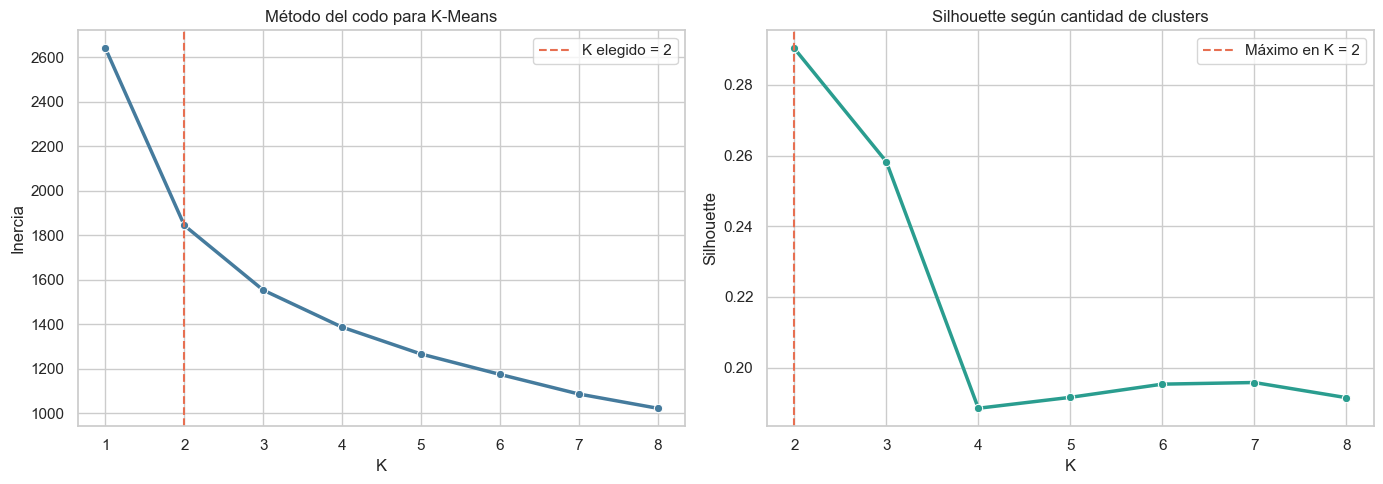

In [9]:
elbow_rows = []
for k in range(1, 9):
    elbow_model = KMeans(n_clusters=k, n_init=30, random_state=RANDOM_STATE).fit(X_scaled)
    elbow_rows.append({'K': k, 'Inercia': elbow_model.inertia_})
elbow_results = pd.DataFrame(elbow_rows)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.lineplot(data=elbow_results, x='K', y='Inercia', marker='o', linewidth=2.5, ax=axes[0], color='#457b9d')
axes[0].axvline(best_k, linestyle='--', color='#e76f51', label=f'K elegido = {best_k}')
axes[0].set_title('Método del codo para K-Means')
axes[0].set_xticks(range(1, 9))
axes[0].legend()
sns.lineplot(data=k_results, x='K', y='Silhouette', marker='o', linewidth=2.5, ax=axes[1], color='#2a9d8f')
axes[1].axvline(best_k, linestyle='--', color='#e76f51', label=f'Máximo en K = {best_k}')
axes[1].set_title('Silhouette según cantidad de clusters')
axes[1].set_xticks(range(2, 9))
axes[1].legend()
plt.tight_layout()
plt.show()

### Interpretación del gráfico del codo

La mayor reducción de inercia ocurre al pasar de un único grupo a dos. A partir de K=2 la curva continúa descendiendo —como sucede necesariamente al agregar centros—, pero las mejoras son más graduales. El codo se encuentra aproximadamente entre K=2 y K=3; para resolver esa ambigüedad se utiliza silhouette, cuyo máximo es K=2 (0,290). Davies-Bouldin y la interpretación comercial se utilizan como comprobaciones adicionales.

Por tanto, **K=2 no se elige solamente porque “se vea” en el codo**: coincide con la mejor separación silhouette, genera grupos de tamaño suficiente y produce dos perfiles comerciales claramente diferenciables.

## 5.2. Tablas de perfiles: K-Means, DBSCAN y ruido

Las tablas utilizan medianas porque las distribuciones de gasto son muy asimétricas. Además del gasto típico, se informa el tamaño y la participación de cada grupo. En DBSCAN, la etiqueta `-1` se presenta separadamente como “Ruido / casos no asignados”.

Tabla de perfiles K-Means (medianas de gasto anual):


,Perfil,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Clientes,Participacion_%
kmeans_cluster,,,,,,,,,
0,Frescos y congelados,10348.000000,1871.000000,2406.000000,2225.000000,328.000000,750.000000,252,57.3%
1,"Almacén, lácteos y limpieza",5406.000000,7690.000000,11527.000000,1062.000000,4495.000000,1388.000000,188,42.7%


Tabla de perfiles DBSCAN, incluyendo ruido (medianas de gasto anual):


,Perfil,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Clientes,Participacion_%
dbscan_cluster,,,,,,,,,
-1,Ruido / no asignados,5858.000000,4038.000000,5030.000000,1030.000000,843.000000,710.000000,248,56.4%
0,Núcleo DBSCAN 0,8449.000000,6662.000000,10538.000000,1370.000000,4039.000000,1702.000000,88,20.0%
1,Núcleo DBSCAN 1,12528.000000,1783.000000,2242.000000,2592.000000,270.000000,834.000000,104,23.6%


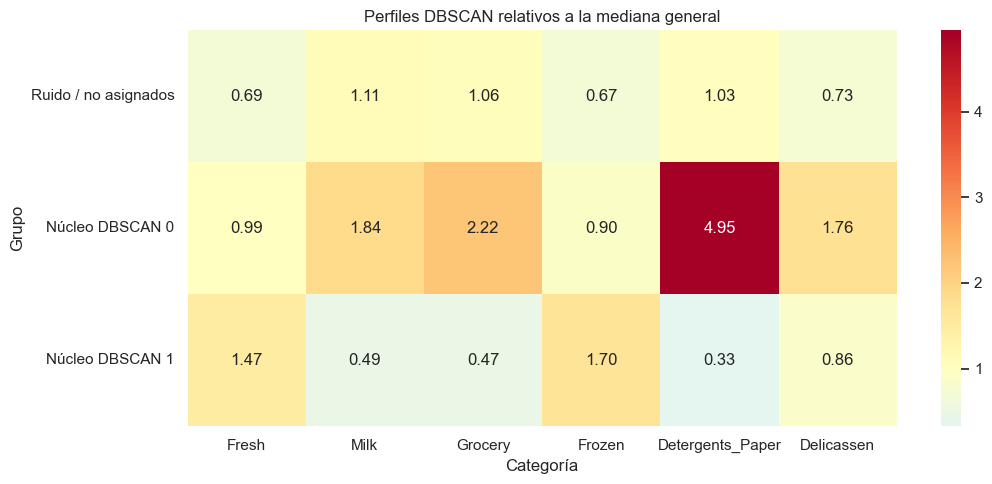

In [10]:
kmeans_profile_table = df.groupby('kmeans_cluster')[spending_cols].median().round(0)
kmeans_profile_table.insert(0, 'Perfil', kmeans_profile_table.index.map({0: 'Frescos y congelados', 1: 'Almacén, lácteos y limpieza'}))
kmeans_counts = df['kmeans_cluster'].value_counts()
kmeans_profile_table['Clientes'] = kmeans_profile_table.index.map(kmeans_counts)
kmeans_profile_table['Participacion_%'] = 100 * kmeans_profile_table['Clientes'] / len(df)
print('Tabla de perfiles K-Means (medianas de gasto anual):')
display(kmeans_profile_table.style.format({'Participacion_%': '{:.1f}%'}))

dbscan_names = {-1: 'Ruido / no asignados'}
for label in sorted(value for value in df['dbscan_cluster'].unique() if value != -1):
    dbscan_names[label] = f'Núcleo DBSCAN {label}'
dbscan_profile_table = df.groupby('dbscan_cluster')[spending_cols].median().round(0)
dbscan_profile_table.insert(0, 'Perfil', dbscan_profile_table.index.map(dbscan_names))
dbscan_counts = df['dbscan_cluster'].value_counts()
dbscan_profile_table['Clientes'] = dbscan_profile_table.index.map(dbscan_counts)
dbscan_profile_table['Participacion_%'] = 100 * dbscan_profile_table['Clientes'] / len(df)
print('Tabla de perfiles DBSCAN, incluyendo ruido (medianas de gasto anual):')
display(dbscan_profile_table.style.format({'Participacion_%': '{:.1f}%'}))

dbscan_relative_profile = df.groupby('dbscan_cluster')[spending_cols].median().div(df[spending_cols].median(), axis=1)
plt.figure(figsize=(11, 5))
sns.heatmap(dbscan_relative_profile.rename(index=dbscan_names), annot=True, fmt='.2f', cmap='RdYlBu_r', center=1)
plt.title('Perfiles DBSCAN relativos a la mediana general')
plt.xlabel('Categoría')
plt.ylabel('Grupo')
plt.tight_layout()
plt.show()

### Interpretación de las tablas

- **K-Means cluster 0 — Frescos y congelados:** concentra 252 clientes y se caracteriza por mayores medianas en Fresh y Frozen, con menor compra de Grocery, Milk y Detergents_Paper.
- **K-Means cluster 1 — Almacén, lácteos y limpieza:** reúne 188 clientes y presenta medianas superiores en Milk, Grocery y Detergents_Paper. Los perfiles son accionables y todos los clientes quedan asignados.
- **DBSCAN:** identifica dos núcleos densos más homogéneos. Estos núcleos ayudan a confirmar que existen patrones de compra reconocibles, pero no representan toda la cartera.
- **Ruido de DBSCAN:** incluye 248 clientes (56,4 %). No significa que todos sean errores o anomalías; son observaciones que no tienen suficientes vecinos dentro del radio elegido. El grupo mezcla compradores extremos y clientes situados entre los dos perfiles densos.

## 5.3. Pruebas adicionales de DBSCAN y análisis de outliers

DBSCAN depende fuertemente de `eps` y `min_samples`. Para documentar esa sensibilidad se muestran todas las combinaciones probadas, incluso las que producen un solo cluster y no permiten calcular silhouette. También se grafica la distancia al décimo vecino: sirve como diagnóstico visual para `min_samples=10` y permite comparar el `eps=0,9` elegido con la estructura de distancias observada.

,eps,min_samples,grupos,ruido_%,cobertura_%,silhouette_sin_ruido
0,0.700000,4,13,66.4%,33.6%,0.106
1,0.700000,6,5,83.0%,17.0%,0.245
2,0.700000,10,1,95.9%,4.1%,nan
3,0.900000,4,4,34.3%,65.7%,-0.136
4,0.900000,6,4,39.8%,60.2%,0.024
5,0.900000,10,2,56.4%,43.6%,0.461
6,1.100000,4,2,18.6%,81.4%,0.154
7,1.100000,6,1,23.2%,76.8%,nan
8,1.100000,10,2,27.7%,72.3%,0.261
9,1.300000,4,1,12.0%,88.0%,nan


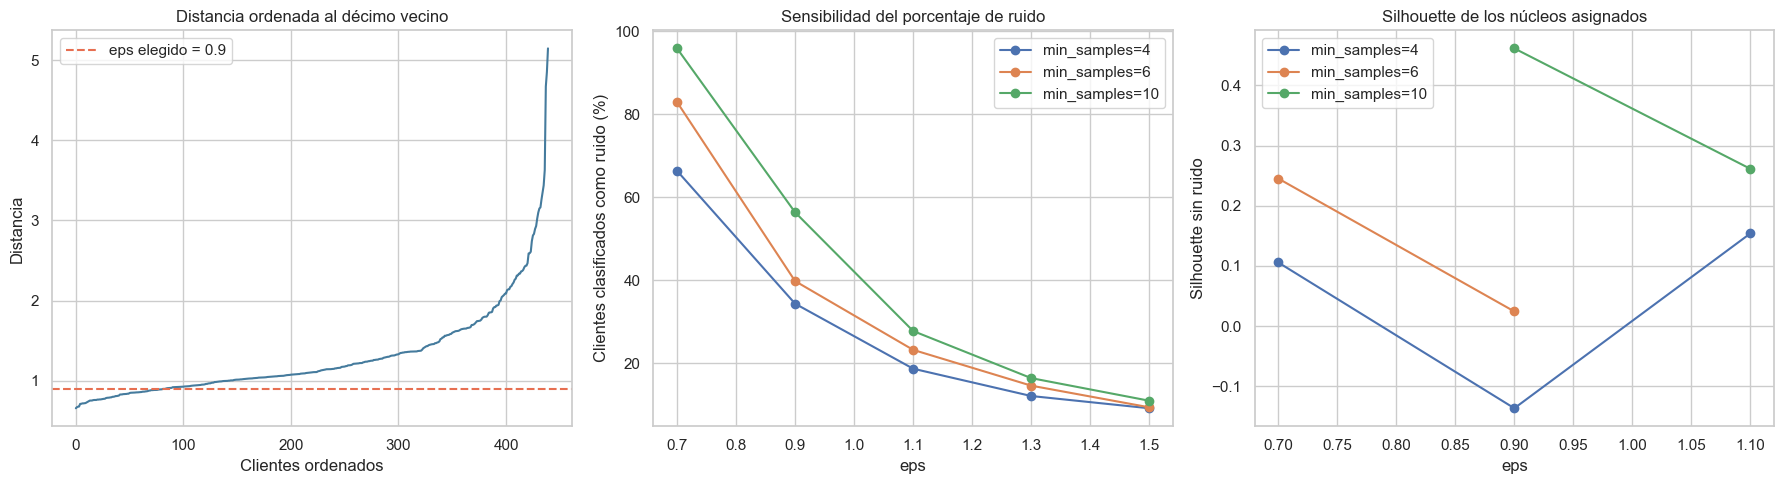

Resumen de casos marcados como ruido por DBSCAN:


,total_spending,distancia_centro_kmeans
count,248.00,248.00
mean,34958.06,2.31
std,32911.88,0.93
min,904.00,1.04
25%,15263.00,1.67
50%,25088.50,2.07
75%,44085.25,2.67
max,199891.00,6.46


Diez casos de ruido más alejados de su centro K-Means:


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,total_spending,kmeans_cluster,distancia_centro_kmeans
154,622,55,137,75,7,8,904,0,6.46
75,20398,1137,3,4407,3,975,26923,0,6.32
338,3,333,7021,15601,15,550,23523,0,6.00
66,9,1534,7417,175,3468,27,12630,1,5.36
128,140,8847,3823,142,1062,3,14017,1,5.24
95,3,2920,6252,440,223,709,10547,1,5.17
183,36847,43950,20170,36534,239,47943,185683,1,4.97
142,37036,7152,8253,2995,20,3,55459,0,4.69
184,327,918,4710,74,334,11,6374,0,4.69
109,1406,16729,28986,673,836,3,48633,1,4.57


In [11]:
from sklearn.neighbors import NearestNeighbors

dbscan_sensitivity_rows = []
for eps in [0.7, 0.9, 1.1, 1.3, 1.5]:
    for min_samples in [4, 6, 10]:
        sensitivity_labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(X_scaled)
        valid = sensitivity_labels != -1
        groups = len(set(sensitivity_labels[valid]))
        score = np.nan
        if valid.sum() > 1 and groups >= 2:
            score = silhouette_score(X_scaled[valid], sensitivity_labels[valid])
        dbscan_sensitivity_rows.append({
            'eps': eps, 'min_samples': min_samples, 'grupos': groups,
            'ruido_%': 100 * (~valid).mean(), 'cobertura_%': 100 * valid.mean(),
            'silhouette_sin_ruido': score
        })
dbscan_sensitivity = pd.DataFrame(dbscan_sensitivity_rows)
display(dbscan_sensitivity.style.format({'ruido_%': '{:.1f}%', 'cobertura_%': '{:.1f}%', 'silhouette_sin_ruido': '{:.3f}'}).highlight_min(subset=['ruido_%'], color='#d8f3dc').highlight_max(subset=['silhouette_sin_ruido'], color='#ffe8a1'))

neighbors = NearestNeighbors(n_neighbors=10).fit(X_scaled)
distances, _ = neighbors.kneighbors(X_scaled)
tenth_neighbor_distance = np.sort(distances[:, -1])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(tenth_neighbor_distance, color='#457b9d')
axes[0].axhline(float(best_db['eps']), linestyle='--', color='#e76f51', label=f"eps elegido = {float(best_db['eps']):.1f}")
axes[0].set_title('Distancia ordenada al décimo vecino')
axes[0].set_xlabel('Clientes ordenados')
axes[0].set_ylabel('Distancia')
axes[0].legend()

for min_samples, subset in dbscan_sensitivity.groupby('min_samples'):
    axes[1].plot(subset['eps'], subset['ruido_%'], marker='o', label=f'min_samples={min_samples}')
axes[1].set_title('Sensibilidad del porcentaje de ruido')
axes[1].set_xlabel('eps')
axes[1].set_ylabel('Clientes clasificados como ruido (%)')
axes[1].legend()

valid_scores = dbscan_sensitivity.dropna(subset=['silhouette_sin_ruido'])
for min_samples, subset in valid_scores.groupby('min_samples'):
    axes[2].plot(subset['eps'], subset['silhouette_sin_ruido'], marker='o', label=f'min_samples={min_samples}')
axes[2].set_title('Silhouette de los núcleos asignados')
axes[2].set_xlabel('eps')
axes[2].set_ylabel('Silhouette sin ruido')
axes[2].legend()
plt.tight_layout()
plt.show()

noise_mask = df['dbscan_cluster'] == -1
distance_to_kmeans_center = np.linalg.norm(X_scaled - kmeans.cluster_centers_[df['kmeans_cluster']], axis=1)
outlier_review = df.loc[noise_mask, spending_cols + ['total_spending', 'kmeans_cluster']].copy()
outlier_review['distancia_centro_kmeans'] = distance_to_kmeans_center[noise_mask]
print('Resumen de casos marcados como ruido por DBSCAN:')
display(outlier_review[['total_spending', 'distancia_centro_kmeans']].describe().round(2))
print('Diez casos de ruido más alejados de su centro K-Means:')
display(outlier_review.sort_values('distancia_centro_kmeans', ascending=False).head(10).round(2))

### Interpretación de las pruebas de DBSCAN y outliers

- Al aumentar `eps`, más clientes quedan conectados y disminuye el porcentaje de ruido, pero los grupos pueden fusionarse. Al aumentar `min_samples`, el criterio de densidad es más exigente y normalmente crece el ruido.
- La configuración elegida (`eps=0,9`, `min_samples=10`) maximiza silhouette entre las alternativas válidas, pero alcanza esa separación conservando únicamente el 43,6 % de los clientes. Por eso su silhouette de 0,461 **no es directamente comparable** con el 0,290 de K-Means sobre el 100 % de la muestra.
- Los casos `-1` deben llamarse “ruido según DBSCAN”, no outliers confirmados. La tabla de mayor distancia al centro K-Means permite priorizar una revisión comercial o de calidad de datos, pero no justifica eliminarlos automáticamente.
- DBSCAN es útil como análisis complementario para identificar núcleos densos y casos inusuales; K-Means resulta más apropiado cuando el objetivo es asignar toda la cartera a segmentos operativos.

## 5.4. Por qué K-Means es la segmentación principal

K-Means se adopta como segmentación principal por la combinación de cuatro evidencias:

1. **Cobertura:** asigna el 100 % de los clientes, mientras DBSCAN deja el 56,4 % como ruido.
2. **Selección consistente de K:** el codo se ubica alrededor de 2–3 grupos y silhouette alcanza su máximo en K=2.
3. **Estabilidad:** las ejecuciones con distintas inicializaciones producen prácticamente la misma asignación (ARI promedio 0,996).
4. **Interpretabilidad comercial:** los dos grupos tienen tamaño relevante y perfiles explicables mediante categorías de compra concretas.

DBSCAN no se descarta como técnica: se conserva como diagnóstico de densidad y outliers. Sin embargo, una segmentación que no asigna a más de la mitad de los clientes es difícil de utilizar para campañas, planificación de inventario o definición de propuestas comerciales para toda la cartera.

## Evaluacion grafica: por que no se utiliza ROC

La curva ROC requiere una variable objetivo con clases conocidas, por ejemplo “si” y “no”. En clustering no existe una respuesta objetivo previa: justamente buscamos descubrir los grupos. Por eso una ROC no seria válida. En su lugar, se utiliza la curva de valores silhouette para analizar la calidad y separacion de los grupos encontrados.

## Metricas no aplicables

La precision es una métrica de clasificación y no corresponde a este ejercicio de clustering, porque no existe una clase objetivo conocida. La calidad de los grupos se evalúa con silhouette, Davies-Bouldin, tamaño de los clusters y coherencia de sus perfiles.

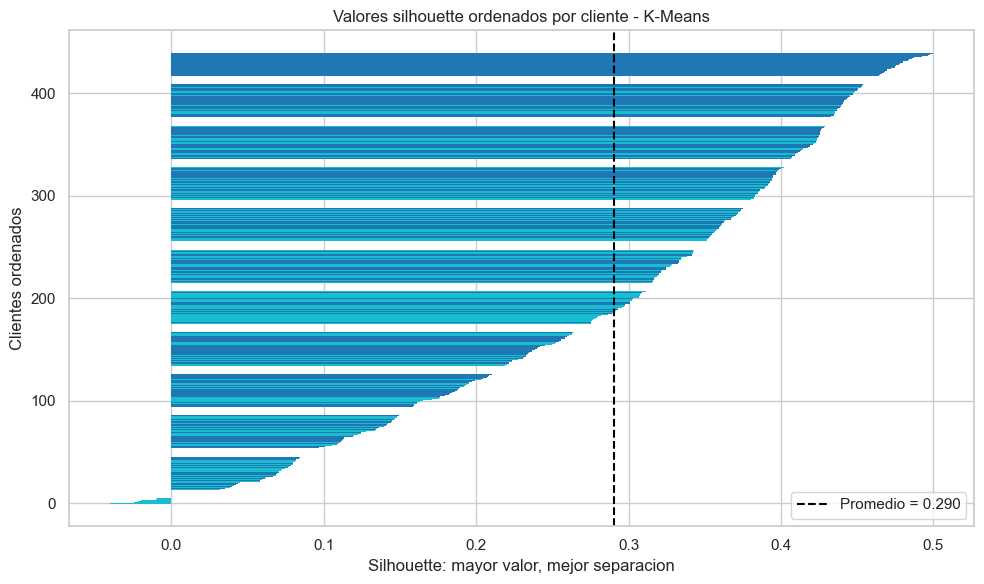

In [12]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples

if 'kmeans_cluster' not in df.columns:
    kmeans = KMeans(n_clusters=best_k, n_init=30, random_state=RANDOM_STATE)
    df['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

silhouette_values = silhouette_samples(X_scaled, df['kmeans_cluster'])
order = np.argsort(silhouette_values)
colors = plt.cm.tab10(df['kmeans_cluster'].to_numpy()[order] / max(1, best_k - 1))
plt.figure(figsize=(10, 6))
plt.barh(np.arange(len(order)), silhouette_values[order], color=colors, edgecolor='none')
plt.axvline(silhouette_values.mean(), linestyle='--', color='black', label=f'Promedio = {silhouette_values.mean():.3f}')
plt.title('Valores silhouette ordenados por cliente - K-Means')
plt.xlabel('Silhouette: mayor valor, mejor separacion')
plt.ylabel('Clientes ordenados')
plt.legend()
plt.tight_layout()
plt.show()

### Hallazgo del gráfico

El silhouette promedio de K-Means es 0,290, lo que indica una estructura de dos grupos reconocible pero no fuertemente separada. La mayoría de los clientes tiene valores positivos, aunque los casos cercanos a cero —y algunos negativos— se encuentran en la frontera entre perfiles y deben interpretarse con cautela.

## 6.1. Caracterización detallada de los clusters

Para que los grupos sean accionables, se comparan sus medianas con la mediana general. Un valor relativo mayor que 1 indica que el cliente típico del cluster compra más que el cliente típico de toda la base en esa categoría. Además, se muestran las distribuciones completas para no ocultar la variabilidad interna.

,Perfil,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Clientes,Participacion_%
kmeans_cluster,,,,,,,,,
0,Frescos y congelados,10348.000000,1871.000000,2406.000000,2225.000000,328.000000,750.000000,252,57.3%
1,"Almacén, lácteos y limpieza",5406.000000,7690.000000,11527.000000,1062.000000,4495.000000,1388.000000,188,42.7%


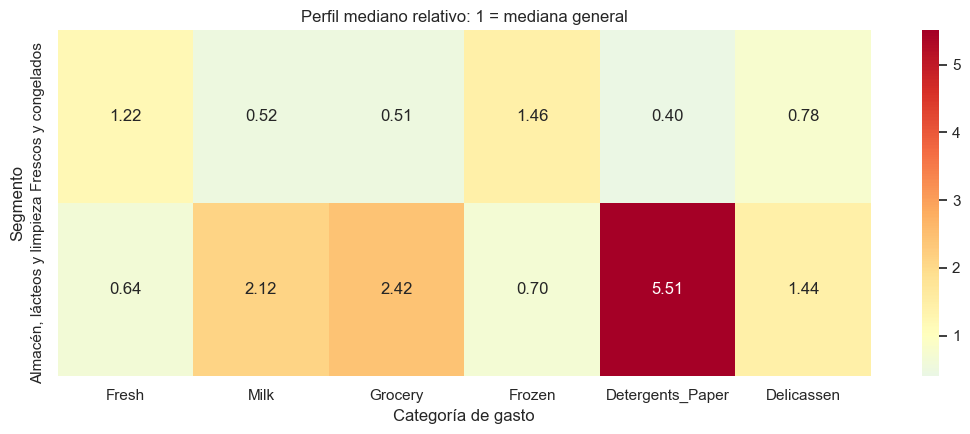

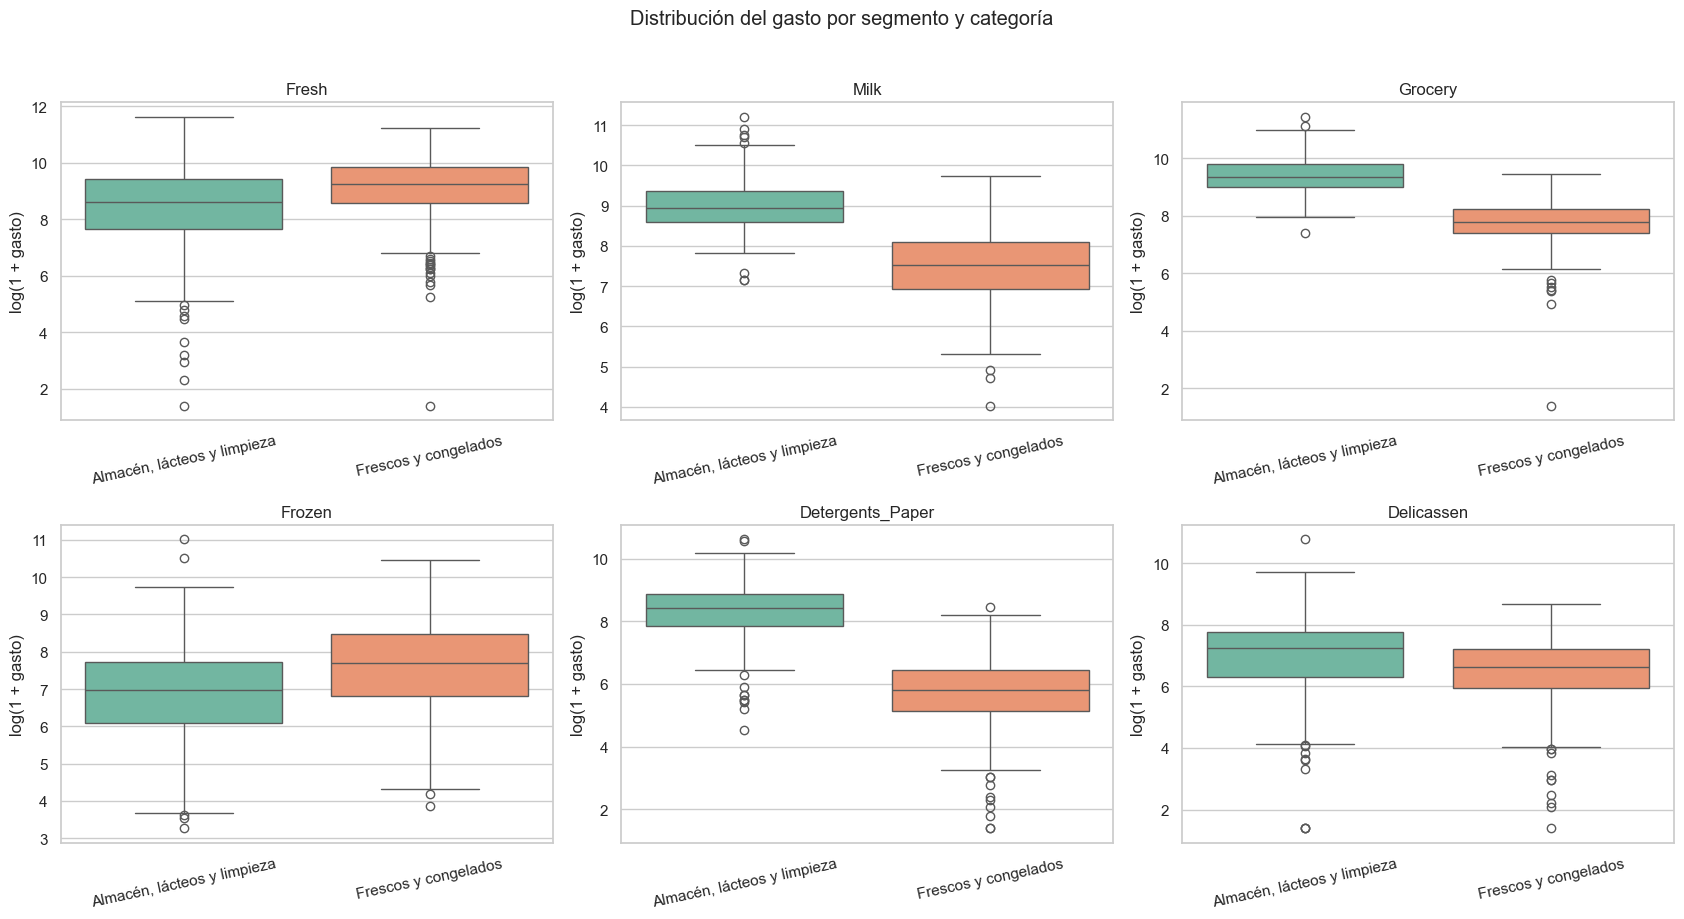

,Categoria,F_ANOVA,p_ANOVA,H_Kruskal,p_Kruskal,Eta_cuadrado
4,Detergents_Paper,616.01,1.5e-85,268.57,2.33e-60,0.584
2,Grocery,539.07,2.5e-78,282.98,1.68e-63,0.552
1,Milk,418.16,9.75e-66,240.89,2.51e-54,0.488
3,Frozen,42.72,1.76e-10,38.54,5.36e-10,0.089
0,Fresh,30.67,5.29e-08,27.91,1.27e-07,0.065
5,Delicassen,13.58,0.000257,23.64,1.16e-06,0.030


In [13]:
from scipy.stats import f_oneway, kruskal
from sklearn.metrics import adjusted_rand_score, calinski_harabasz_score

overall_median = df[spending_cols].median()
relative_profile = profile.div(overall_median, axis=1)
cluster_names = {
    relative_profile['Fresh'].idxmax(): 'Frescos y congelados',
    relative_profile['Grocery'].idxmax(): 'Almacén, lácteos y limpieza'
}
df['segmento_kmeans'] = df['kmeans_cluster'].map(cluster_names)

profile_business = profile.copy()
profile_business.insert(0, 'Perfil', [cluster_names[index] for index in profile_business.index])
profile_business['Clientes'] = df['kmeans_cluster'].value_counts().sort_index()
profile_business['Participacion_%'] = 100 * profile_business['Clientes'] / len(df)
display(profile_business.style.format({'Participacion_%': '{:.1f}%'}))

plt.figure(figsize=(11, 4.5))
sns.heatmap(relative_profile.rename(index=cluster_names), annot=True, fmt='.2f', cmap='RdYlBu_r', center=1)
plt.title('Perfil mediano relativo: 1 = mediana general')
plt.xlabel('Categoría de gasto')
plt.ylabel('Segmento')
plt.tight_layout()
plt.show()

cluster_long = df.melt(id_vars=['segmento_kmeans'], value_vars=spending_cols, var_name='Categoria', value_name='Gasto')
cluster_long['log_gasto'] = np.log1p(cluster_long['Gasto'])
fig, axes = plt.subplots(2, 3, figsize=(17, 9))
for ax, category in zip(axes.ravel(), spending_cols):
    subset = cluster_long[cluster_long['Categoria'] == category]
    sns.boxplot(data=subset, x='segmento_kmeans', y='log_gasto', hue='segmento_kmeans', legend=False, ax=ax, palette='Set2')
    ax.set_title(category)
    ax.set_xlabel('')
    ax.set_ylabel('log(1 + gasto)')
    ax.tick_params(axis='x', rotation=12)
plt.suptitle('Distribución del gasto por segmento y categoría', y=1.02)
plt.tight_layout()
plt.show()

anova_rows = []
for column in spending_cols:
    groups = [np.log1p(group[column].to_numpy()) for _, group in df.groupby('kmeans_cluster')]
    f_stat, anova_p = f_oneway(*groups)
    h_stat, kruskal_p = kruskal(*groups)
    log_values = np.log1p(df[column])
    grand_mean = log_values.mean()
    ss_between = sum(len(group) * (np.log1p(group[column]).mean() - grand_mean) ** 2 for _, group in df.groupby('kmeans_cluster'))
    eta_squared = ss_between / ((log_values - grand_mean) ** 2).sum()
    anova_rows.append({'Categoria': column, 'F_ANOVA': f_stat, 'p_ANOVA': anova_p, 'H_Kruskal': h_stat, 'p_Kruskal': kruskal_p, 'Eta_cuadrado': eta_squared})
cluster_tests = pd.DataFrame(anova_rows).sort_values('Eta_cuadrado', ascending=False)
display(cluster_tests.style.format({'F_ANOVA': '{:.2f}', 'p_ANOVA': '{:.3g}', 'H_Kruskal': '{:.2f}', 'p_Kruskal': '{:.3g}', 'Eta_cuadrado': '{:.3f}'}))

### Interpretación de cada subgrupo

- **Cluster 0 — Frescos y congelados (252 clientes; 57,3 %):** su cliente típico compra más Fresh y Frozen, pero menos Milk, Grocery y Detergents_Paper. Es compatible con restaurantes, hoteles o comercios que priorizan insumos perecederos. Acciones posibles: reposición frecuente, cadena de frío, descuentos por volumen y paquetes de frescos con congelados.
- **Cluster 1 — Almacén, lácteos y limpieza (188 clientes; 42,7 %):** presenta medianas muy superiores en Milk, Grocery y Detergents_Paper, y menor gasto típico en Fresh y Frozen. Es compatible con minoristas o comercios con surtido de productos envasados y de limpieza. Acciones posibles: promociones cruzadas, contratos de abastecimiento y beneficios por compras recurrentes.

Los nombres son etiquetas comerciales interpretativas, no tipos de negocio observados directamente. Deben validarse con el equipo comercial y, si es posible, con información externa sobre cada cliente.

## 6.2. Evidencia para elegir K-Means frente a DBSCAN

La comparación no puede apoyarse solo en silhouette, porque DBSCAN calcula esa métrica después de retirar el ruido. Se agregan cobertura, estabilidad ante inicializaciones y Calinski-Harabasz. También se distingue entre significación estadística y relevancia práctica: con muchos datos, una diferencia puede ser significativa pero pequeña; por eso se reporta eta cuadrado como tamaño de efecto.

,Algoritmo,Clientes_asignados_%,Silhouette,Davies_Bouldin,Calinski_Harabasz
0,K-Means,100.0%,0.290,1.352,189.0
1,DBSCAN (sin ruido),43.6%,0.461,0.858,236.7


,count,mean,std,min,25%,50%,75%,max
Estabilidad ARI,30.000,0.996,0.005,0.991,0.991,1.000,1.000,1.000


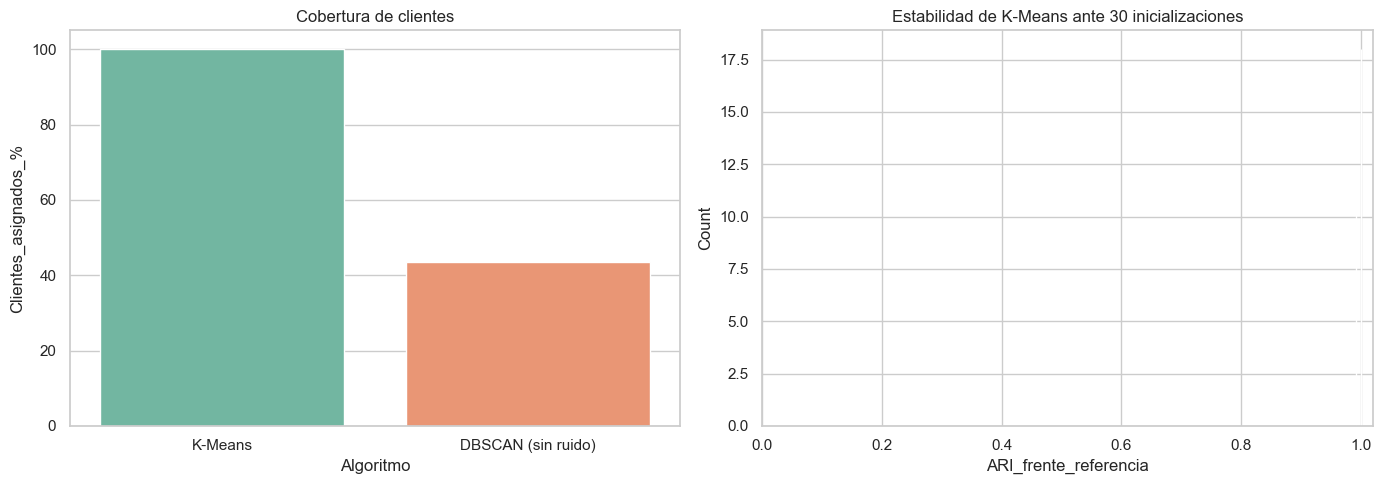

In [14]:
kmeans_silhouette = silhouette_score(X_scaled, df['kmeans_cluster'])
kmeans_db = davies_bouldin_score(X_scaled, df['kmeans_cluster'])
kmeans_ch = calinski_harabasz_score(X_scaled, df['kmeans_cluster'])
db_valid = df['dbscan_cluster'] != -1
db_coverage = db_valid.mean()
db_silhouette = silhouette_score(X_scaled[db_valid], df.loc[db_valid, 'dbscan_cluster'])
db_db = davies_bouldin_score(X_scaled[db_valid], df.loc[db_valid, 'dbscan_cluster'])
db_ch = calinski_harabasz_score(X_scaled[db_valid], df.loc[db_valid, 'dbscan_cluster'])

algorithm_comparison = pd.DataFrame([
    {'Algoritmo': 'K-Means', 'Clientes_asignados_%': 100.0, 'Silhouette': kmeans_silhouette, 'Davies_Bouldin': kmeans_db, 'Calinski_Harabasz': kmeans_ch},
    {'Algoritmo': 'DBSCAN (sin ruido)', 'Clientes_asignados_%': 100 * db_coverage, 'Silhouette': db_silhouette, 'Davies_Bouldin': db_db, 'Calinski_Harabasz': db_ch}
])
display(algorithm_comparison.style.format({'Clientes_asignados_%': '{:.1f}%', 'Silhouette': '{:.3f}', 'Davies_Bouldin': '{:.3f}', 'Calinski_Harabasz': '{:.1f}'}))

reference_labels = KMeans(n_clusters=best_k, n_init=30, random_state=RANDOM_STATE).fit_predict(X_scaled)
stability_rows = []
for seed in range(30):
    candidate_labels = KMeans(n_clusters=best_k, n_init=1, random_state=seed).fit_predict(X_scaled)
    stability_rows.append({'Semilla': seed, 'ARI_frente_referencia': adjusted_rand_score(reference_labels, candidate_labels)})
stability_df = pd.DataFrame(stability_rows)
display(stability_df['ARI_frente_referencia'].describe().rename('Estabilidad ARI').to_frame().T.style.format('{:.3f}'))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=algorithm_comparison, x='Algoritmo', y='Clientes_asignados_%', hue='Algoritmo', legend=False, ax=axes[0], palette='Set2')
axes[0].set_ylim(0, 105)
axes[0].set_title('Cobertura de clientes')
sns.histplot(data=stability_df, x='ARI_frente_referencia', bins=10, ax=axes[1], color='#457b9d')
axes[1].set_xlim(0, 1.02)
axes[1].set_title('Estabilidad de K-Means ante 30 inicializaciones')
plt.tight_layout()
plt.show()

### Conclusión del modelo de clustering

- **K = 2 es preferible dentro de K-Means** porque logra el silhouette más alto entre K=2 y K=8. Su valor de 0,290 es moderado: los perfiles existen, pero no forman fronteras perfectas.
- **DBSCAN separa mejor sus dos núcleos densos** cuando se excluye el ruido, pero deja sin segmento al 56,4 % de los clientes. Esa cobertura limitada impide usarlo como segmentación principal de toda la cartera; sí es útil como detector de clientes atípicos.
- **K-Means se elige como modelo final** porque asigna al 100 % de los clientes, produce dos grupos de tamaño relevante, genera perfiles comerciales claros y puede evaluarse por estabilidad ante distintas inicializaciones.
- **ANOVA y Kruskal-Wallis** comprueban qué categorías difieren entre grupos, mientras que eta cuadrado muestra la magnitud de esas diferencias. Estas pruebas describen clusters construidos con las mismas variables y, por tanto, no deben presentarse como una validación externa independiente.

Para stakeholders, el resultado se comunica mejor con nombres de perfiles, medianas relativas, tamaño del segmento y acciones posibles. Antes de implementar campañas conviene validar los segmentos en otro período y medir si responden de forma distinta a acciones comerciales reales.

## 6. Interpretacion de resultados

Los gráficos de perfiles, tamaños de cluster y silhouette permiten evaluar la calidad y utilidad de los agrupamientos.

## 7. Justificacion de la seleccion de algoritmos e interpretacion

### Objetivo del analisis

En este ejercicio no existe una respuesta correcta previamente definida. El algoritmo recibe los gastos de cada cliente y busca clientes con comportamientos parecidos. Por eso los grupos no son “buenos” o “malos”: son perfiles que deben interpretarse con el contexto del negocio.

### Criterio para seleccionar los algoritmos

Se comparan dos estrategias porque responden a preguntas diferentes. K-Means busca grupos compactos y requiere definir cuántos grupos se desean analizar. DBSCAN busca zonas de alta densidad, no obliga a fijar de antemano la cantidad de grupos y puede identificar observaciones atipicas. La comparación permite evaluar si los perfiles encontrados son compactos, separados y útiles para el negocio.

**K-Means.** Primero se elige una cantidad de grupos, K. El algoritmo ubica un centro para cada grupo y asigna cada cliente al centro mas cercano. Luego mueve los centros y repite el proceso hasta que los grupos se estabilizan. Es util para encontrar perfiles relativamente compactos, pero hay que decidir K y cada cliente debe quedar asignado a algun grupo.

**DBSCAN.** No necesita indicar de antemano cuántos grupos existen. Busca zonas donde hay muchos clientes cercanos entre si. Los clientes aislados pueden quedar como ruido, identificados con la etiqueta `-1`. Es valioso para encontrar perfiles irregulares y detectar clientes atipicos, aunque depende bastante de los parametros `eps` y `min_samples`.

### Preparacion y criterios de evaluacion

Los gastos tienen escalas muy distintas y algunos clientes gastan muchisimo mas que el promedio. `log1p` reduce el peso de esas diferencias extremas y la estandarizacion coloca las categorias en escalas comparables. Asi, una categoria no domina el agrupamiento solo porque sus numeros sean mas grandes.

- **Silhouette:** indica si cada cliente esta mas cerca de su propio grupo que de los otros. Valores mayores suelen indicar grupos mejor separados.
- **Davies-Bouldin:** compara la dispersion interna de los grupos con la distancia entre ellos. Valores menores suelen ser mejores.
- **Cantidad de clientes por grupo:** ayuda a saber si un perfil es relevante o si solo contiene unos pocos casos.
- **Perfil por medianas:** resume el gasto tipico de cada grupo y permite ponerle un nombre comprensible, como “clientes orientados a productos frescos” o “clientes con alto gasto en grocery y detergentes”.

La proyeccion PCA del grafico reduce seis categorias a dos ejes para poder visualizar los datos. Es una ayuda visual: que dos puntos se vean cerca en el grafico no significa necesariamente que sean iguales en todas las dimensiones originales.

**Decision final:** un segmento es util cuando es interpretable, tiene suficiente cantidad de clientes, presenta una buena separacion y se mantiene razonablemente estable. Antes de tomar decisiones comerciales conviene validarlo con expertos del negocio y con datos de otros periodos.